In [14]:
# ==========================================================
# DISTILGPT-2 STORY CONTINUATION WITH LoRA + METRIC EVAL
# (structured like GPT-Neo reference code)
# ==========================================================

# === Cell 0: Install dependencies (Colab only) ===

!pip install -q transformers datasets accelerate peft evaluate sentence-transformers nltk sacrebleu rouge-score bert-score

In [15]:
# === Cell 1: Imports & Global Config ===
# (No pip uninstall/install here to avoid runtime restart warnings)

import os
import re
import math
import random
from typing import List

import numpy as np
import torch
import nltk
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset, DatasetDict
from nltk import sent_tokenize
from sentence_transformers import SentenceTransformer
from evaluate import load
from rouge_score import rouge_scorer
from torch.nn import CrossEntropyLoss
from IPython.display import display

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling,
    logging as hf_logging,
)

from peft import LoraConfig, get_peft_model

# Download NLTK tokenizers
nltk.download("punkt")
try:
    nltk.download("punkt_tab")
except:
    pass

# --- Global parameters ---
MODEL_NAME         = "distilgpt2"
HF_DATASET         = "mintujupally/ROCStories"   # fixed typo HIF_DATASET -> HF_DATASET
OUTPUT_DIR         = "/content/distilgpt2_lora_rocstories"

BATCH_SIZE         = 32
EPOCHS             = 1
LEARNING_RATE      = 2e-4
MAX_LENGTH         = 128        # max tokens for prompt+target
MAX_NEW_TOKENS     = 40         # max tokens for generated ending
EVAL_SIZE          = 500        # not used directly but kept for parity
SEED               = 42
DEVICE             = "cuda" if torch.cuda.is_available() else "cpu"

# Set seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

print("Using device:", DEVICE)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

# Suppress noisy transformers logs
hf_logging.set_verbosity_error()


Using device: cuda
NumPy version: 1.26.0
Pandas version: 2.2.2


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [16]:
# === Cell 2: Helper functions ===

def first_sentence_only(text: str) -> str:
    """Return only the first sentence from text (for evaluation/generation)."""
    if not text:
        return text
    text = text.strip()
    # regex-based first sentence extraction
    m = re.search(r"(.+?[.!?])(?:\s|$)", text)
    if m:
        return m.group(1).strip()
    # fallback to nltk
    sents = sent_tokenize(text)
    return sents[0].strip() if sents else text


def extract_4_and_5(example):
    """
    From a multi-sentence story, return:
      - prompt: first 4 sentences
      - target: 5th sentence
    Stories with <5 sentences are filtered out.
    """
    text = example.get("text", "")
    sents = re.split(r"(?<=[.!?])\s+", text.strip())
    if len(sents) >= 5:
        return {
            "prompt": " ".join(sents[:4]).strip(),
            "target": sents[4].strip(),
        }
    else:
        return {"prompt": None, "target": None}

In [17]:
# === Cell 3: Load & prepare dataset ===
raw = load_dataset(HF_DATASET)

def prepare_dataset_split(ds):
    ds = ds.map(extract_4_and_5, remove_columns=ds.column_names)
    ds = ds.filter(lambda x: x["prompt"] is not None and x["target"] is not None)
    return ds

dataset = {split: prepare_dataset_split(raw[split]) for split in raw.keys()}
ds = DatasetDict(dataset)

print("✅ Dataset ready:", {k: len(v) for k, v in ds.items()})


Repo card metadata block was not found. Setting CardData to empty.


✅ Dataset ready: {'train': 77688, 'test': 19410}


In [18]:
# === Cell 4: Tokenizer & Base Model ===
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.to(DEVICE)

def tokenize_fn(example):
    """
    Build a single sequence:
      [4-sentence prompt] [EOS] [gold 5th sentence]
    and train DistilGPT-2 in causal LM fashion.
    """
    full = example["prompt"].strip() + " " + tokenizer.eos_token + " " + example["target"].strip()
    tok = tokenizer(
        full,
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length",
    )
    tok["labels"] = tok["input_ids"].copy()
    return tok

tokenized = ds.map(
    tokenize_fn,
    remove_columns=ds["train"].column_names,
    desc="Tokenizing",
)
tokenized.set_format(type="torch")
print("✅ Tokenization done")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Tokenizing:   0%|          | 0/77688 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/19410 [00:00<?, ? examples/s]

✅ Tokenization done


In [19]:
# === Cell 5: LoRA setup ===
# For GPT-2 / DistilGPT-2, typical LoRA target is "c_attn"
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["c_attn"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


trainable params: 147,456 || all params: 82,060,032 || trainable%: 0.17969283755580304


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:1059: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


In [20]:
# === Cell 6: Training ===
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    overwrite_output_dir=True,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    evaluation_strategy="epoch",     # correct arg name (not eval_strategy)
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    warmup_steps=200,
    weight_decay=0.01,
    fp16=(DEVICE == "cuda"),
    logging_steps=500,
    save_total_limit=2,
    save_strategy="epoch",
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"].select(
        range(min(1000, len(tokenized["test"])))
    ),
    data_collator=data_collator,
)

trainer.train()

# Save model + tokenizer
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)


/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:436: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:469: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


{'loss': 3.5659, 'grad_norm': 0.5493001937866211, 'learning_rate': 0.00017307001795332136, 'epoch': 0.21}
{'loss': 3.2922, 'grad_norm': 0.664681613445282, 'learning_rate': 0.0001281867145421903, 'epoch': 0.41}
{'loss': 3.266, 'grad_norm': 0.6878736019134521, 'learning_rate': 8.330341113105925e-05, 'epoch': 0.62}
{'loss': 3.2492, 'grad_norm': 0.7660027146339417, 'learning_rate': 3.842010771992819e-05, 'epoch': 0.82}
{'eval_loss': 3.1164684295654297, 'eval_runtime': 2.3087, 'eval_samples_per_second': 433.147, 'eval_steps_per_second': 13.861, 'epoch': 1.0}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


{'train_runtime': 384.9028, 'train_samples_per_second': 201.838, 'train_steps_per_second': 6.308, 'train_loss': 3.3245084910259215, 'epoch': 1.0}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


('/content/distilgpt2_lora_rocstories/tokenizer_config.json',
 '/content/distilgpt2_lora_rocstories/special_tokens_map.json',
 '/content/distilgpt2_lora_rocstories/vocab.json',
 '/content/distilgpt2_lora_rocstories/merges.txt',
 '/content/distilgpt2_lora_rocstories/added_tokens.json',
 '/content/distilgpt2_lora_rocstories/tokenizer.json')

In [21]:
# === Cell 7: Perplexity on eval set ===
eval_results = trainer.evaluate()
eval_loss = eval_results["eval_loss"]
perplexity = math.exp(eval_loss)
print(f"Perplexity on held-out set (DistilGPT-2 + LoRA): {perplexity:.2f}")

{'eval_loss': 3.1164684295654297, 'eval_runtime': 2.3028, 'eval_samples_per_second': 434.256, 'eval_steps_per_second': 13.896, 'epoch': 1.0}
Perplexity on held-out set (DistilGPT-2 + LoRA): 22.57


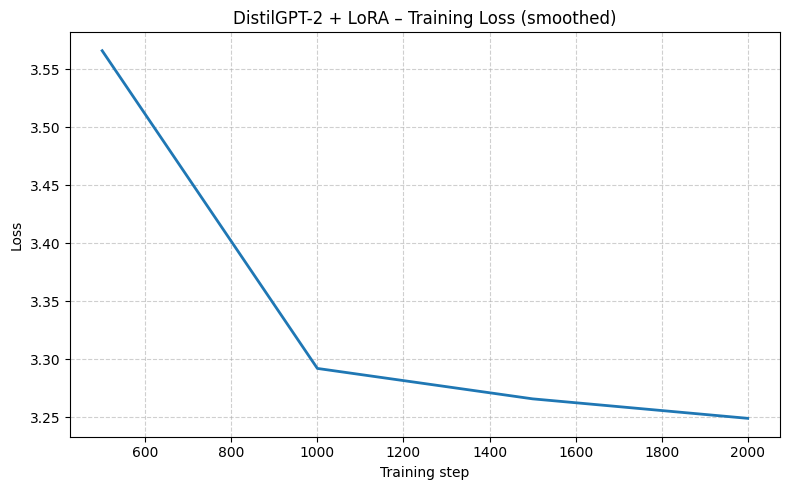

In [22]:
# === Cell 8: Training Loss Curve (smoothed, like reference) ===
logs = trainer.state.log_history
train_steps, train_losses = [], []

for log in logs:
    if "loss" in log and "step" in log:
        train_steps.append(log["step"])
        train_losses.append(log["loss"])

train_steps  = np.array(train_steps)
train_losses = np.array(train_losses)

window = 50
if len(train_losses) >= window:
    kernel = np.ones(window) / window
    train_losses_smooth = np.convolve(train_losses, kernel, mode="valid")
    train_steps_smooth  = train_steps[window - 1:]
else:
    train_losses_smooth = train_losses
    train_steps_smooth  = train_steps

plt.figure(figsize=(8, 5))
plt.plot(train_steps_smooth, train_losses_smooth, linewidth=2)
plt.title("DistilGPT-2 + LoRA – Training Loss (smoothed)")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [23]:
# === Cell 9: Generation utilities (same pattern as reference) ===

def generate_completion(
    model,
    tokenizer,
    prompt: str,
    decoding: str = "greedy",
    temperature: float = 1.0,
    top_p: float = 0.9,
    max_new_tokens: int = MAX_NEW_TOKENS,
    stop_at_first_sentence: bool = True,
    max_tokens_first_sentence: int = 30,  # hard token limit for first sentence
):
    """
    Generate a one-sentence ending for a 4-sentence prompt
    using greedy / temperature / top-p decoding.
    """
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt", padding=True).to(DEVICE)

    gen_kwargs = dict(
        max_new_tokens=max_new_tokens,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    if decoding == "greedy":
        outputs = model.generate(**inputs, do_sample=False, **gen_kwargs)
    elif decoding == "temperature":
        outputs = model.generate(
            **inputs,
            do_sample=True,
            temperature=temperature,
            **gen_kwargs,
        )
    elif decoding == "top_p":
        outputs = model.generate(
            **inputs,
            do_sample=True,
            top_p=top_p,
            temperature=temperature,
            **gen_kwargs,
        )
    else:
        raise ValueError("decoding must be one of 'greedy', 'temperature', 'top_p'")

    generated = tokenizer.decode(
        outputs[0, inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True,
    )

    if stop_at_first_sentence:
        first_sent = first_sentence_only(generated)
        # enforce hard max token limit on the first sentence
        tok_sent = tokenizer(
            first_sent, truncation=True, max_length=max_tokens_first_sentence
        )
        generated = tokenizer.decode(tok_sent["input_ids"], skip_special_tokens=True)

    return generated.strip()


def batched_generate(
    model,
    tokenizer,
    prompts: List[str],
    decoding: str = "greedy",
    max_new_tokens: int = MAX_NEW_TOKENS,
    batch_size: int = 16,
    stop_at_first_sentence: bool = True,
    temperature: float = 1.0,
    top_p: float = 0.9,
):
    """
    Batched generation over a list of prompts.
    """
    model.eval()
    out = []
    for i in range(0, len(prompts), batch_size):
        batch = prompts[i : i + batch_size]
        enc = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
        ).to(DEVICE)

        gen_kwargs = dict(
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

        if decoding == "greedy":
            outputs = model.generate(**enc, do_sample=False, **gen_kwargs)
        elif decoding == "temperature":
            outputs = model.generate(
                **enc, do_sample=True, temperature=temperature, **gen_kwargs
            )
        elif decoding == "top_p":
            outputs = model.generate(
                **enc, do_sample=True, top_p=top_p, temperature=temperature, **gen_kwargs
            )
        else:
            raise ValueError("decoding must be one of 'greedy', 'temperature', 'top_p'")

        for k in range(outputs.size(0)):
            gen_tokens = outputs[k, enc["input_ids"].shape[1] :]
            text = tokenizer.decode(gen_tokens, skip_special_tokens=True)
            if stop_at_first_sentence:
                text = first_sentence_only(text)
            out.append(text.strip())
    return out


# Quick sanity check
example = ds["test"][0]
print("PROMPT:", example["prompt"])
print("GOLD  :", example["target"])
print("PRED  :", generate_completion(model, tokenizer, example["prompt"], decoding="top_p"))


PROMPT: David had achieved his lifelong goal. He had just become a pilot! He had learned how to fly many kinds of planes. He decided to buy a small plane of his own.
GOLD  : He couldn't wait to get up in the air.
PRED  : He had planned to fly his first one.


In [24]:
# === Cell 10: Metrics setup (BLEU, ROUGE, BERTScore) ===
bleu_metric = load("sacrebleu")
rouge_metric = load("rouge")
bertscore_metric = load("bertscore")

def rougeL_recall_macro(preds: List[str], refs: List[str]) -> float:
    """
    Compute macro-average ROUGE-L recall over all (pred, ref) pairs.
    """
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    recalls = []
    for p, r in zip(preds, refs):
        score = scorer.score(r, p)["rougeL"]
        recalls.append(score.recall)
    return float(np.mean(recalls)) if recalls else 0.0


def bertscore_f1_mean(preds: List[str], refs: List[str], chunk: int = 2000) -> float:
    """
    Compute mean BERTScore-F1 over all predictions (in chunks to avoid OOM).
    """
    f1_all = []
    for i in range(0, len(preds), chunk):
        bpred = preds[i : i + chunk]
        bref = refs[i : i + chunk]
        bs = bertscore_metric.compute(
            predictions=bpred,
            references=bref,
            lang="en",
        )
        f1_all.extend(bs["f1"])
    return float(np.mean(f1_all)) if f1_all else 0.0

In [25]:
# === Cell 11: Semantic coherence (Sentence-BERT cosine similarity) ===
embedder = SentenceTransformer("all-MiniLM-L6-v2", device=DEVICE)

def semantic_coherence_score(preds: List[str], refs: List[str]) -> float:
    """
    Mean cosine similarity between predicted endings and reference endings.
    Mapped from [-1, 1] to [0, 1].
    """
    if not preds:
        return 0.0
    emb_preds = embedder.encode(
        preds, convert_to_numpy=True, show_progress_bar=False
    )
    emb_refs = embedder.encode(
        refs, convert_to_numpy=True, show_progress_bar=False
    )

    norms_p = np.linalg.norm(emb_preds, axis=1)
    norms_r = np.linalg.norm(emb_refs, axis=1)
    dot = np.sum(emb_preds * emb_refs, axis=1)
    cos = dot / (norms_p * norms_r + 1e-12)
    cos01 = (cos + 1.0) / 2.0
    return float(np.mean(cos01))


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [26]:
# === Cell 12: Perplexity on generated continuations ===
def continuation_perplexity_generated(
    model,
    tokenizer,
    prompts,
    preds,
    device,
    max_length=128,
    batch_size=16,
):
    """
    Perplexity of the generated continuations given the prompts.
    Loss only computed on continuation tokens, not the prompt.
    """
    model.eval()
    losses = []
    for i in range(0, len(prompts), batch_size):
        bp = prompts[i : i + batch_size]
        br = preds[i : i + batch_size]
        full_texts = [p + " " + tokenizer.eos_token + " " + r for p, r in zip(bp, br)]
        enc = tokenizer(
            full_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length,
        ).to(device)

        labels = enc["input_ids"].clone()
        labels[enc["attention_mask"] == 0] = -100

        # mask prompt tokens
        prompt_lens = [
            tokenizer(
                p + " " + tokenizer.eos_token,
                return_tensors="pt",
            ).input_ids.shape[1]
            for p in bp
        ]
        for row, pl in enumerate(prompt_lens):
            labels[row, :pl] = -100

        with torch.no_grad():
            loss = model(**enc, labels=labels).loss
            losses.append(loss.item())

    return float(np.exp(np.mean(losses))) if losses else float("inf")


In [28]:
# === Cell 13: Evaluation on FULL test set (Greedy / Temp / Top-p) ===
def evaluate_strategy_full(model, tokenizer, prompts, refs, decoding_type: str):
    """
    Evaluate a decoding strategy on the FULL test set.
    Returns BLEU, ROUGE-L (F1 + Recall), BERTScore-F1, Semantic coherence,
    and perplexity on generated continuations.
    """
    preds = batched_generate(
        model,
        tokenizer,
        prompts,
        decoding=decoding_type,
        max_new_tokens=MAX_NEW_TOKENS,
        batch_size=16,
    )

    # Avoid crashes from empty predictions
    safe_preds_for_overlap = [p if p.strip() else " " for p in preds]

    # BLEU
    bleu = bleu_metric.compute(
        predictions=safe_preds_for_overlap,
        references=[[r] for r in refs],
    )["score"]

    # ROUGE-L F1 + Recall
    rouge_f1 = rouge_metric.compute(
        predictions=safe_preds_for_overlap,
        references=refs,
        use_stemmer=True,
        use_aggregator=True,
        rouge_types=["rougeL"],
    )
    rougeL_f1 = float(rouge_f1["rougeL"])
    rougeL_recall = rougeL_recall_macro(safe_preds_for_overlap, refs)

    # Filter empties for BERTScore & semantic coherence
    non_empty_preds = [p for p in preds if p.strip()]
    non_empty_refs = [r for p, r in zip(preds, refs) if p.strip()]

    if non_empty_preds:
        bs_f1 = bertscore_f1_mean(non_empty_preds, non_empty_refs)
        coherence = semantic_coherence_score(non_empty_preds, non_empty_refs)
    else:
        bs_f1 = 0.0
        coherence = 0.0

    # Perplexity on generated continuations
    ppl_generated = continuation_perplexity_generated(
        model,
        tokenizer,
        prompts,
        preds,
        DEVICE,
        max_length=MAX_LENGTH,
        batch_size=16,
    )

    return {
        "BLEU": bleu,
        "ROUGE_F1": rougeL_f1,
        "ROUGE_Recall": rougeL_recall,
        "BERTScore-F1": bs_f1,
        "SemanticCoherence": coherence,
        "Perplexity": ppl_generated,
    }


import warnings
warnings.filterwarnings(
    "ignore",
    message="A decoder-only architecture is being used, but right-padding was detected!",
)

# Ensure left padding for decoder-only model
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Prepare full test prompts/targets
_prompts = [ex["prompt"] for ex in ds["test"]]
_targets = [ex["target"] for ex in ds["test"]]

# 1) Evaluate 3 decoding strategies on FULL test set
results = {
    dec: evaluate_strategy_full(model, tokenizer, _prompts, _targets, dec)
    for dec in ["greedy", "temperature", "top_p"]
}

df_results = pd.DataFrame(results).T.round(6)
print(f"=== Decoding Evaluation Results (FULL test set: {len(_prompts)} samples) ===")
display(df_results)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

=== Decoding Evaluation Results (FULL test set: 19410 samples) ===


,BLEU,ROUGE_F1,ROUGE_Recall,BERTScore-F1,SemanticCoherence,Perplexity
greedy,1.505429,0.167255,0.164143,0.884865,0.707220,1007.185660
temperature,0.572256,0.128351,0.134425,0.875496,0.680261,1945.302774
top_p,0.604130,0.135095,0.140257,0.877465,0.686119,1678.235557


In [29]:
# === Cell 14: GOLD continuation perplexity (references) ===
def gold_continuation_perplexity(model, tokenizer, prompts, targets, max_length=128):
    """
    Perplexity of the GOLD continuation (reference 5th sentence) given the prompt.
    Only the target part is used for loss.
    """
    model.eval()
    losses = []
    loss_fn = CrossEntropyLoss()

    for prompt, target in zip(prompts, targets):
        full_text = prompt + " " + target
        enc = tokenizer(
            full_text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=max_length,
        )
        ids = enc["input_ids"].to(model.device)

        # boundary where target begins
        prompt_ids = tokenizer(prompt, return_tensors="pt")["input_ids"][0]
        target_start = len(prompt_ids)

        with torch.no_grad():
            logits = model(ids).logits[:, :-1, :]
            labels = ids[:, 1:].clone()
            labels[:, :target_start] = -100  # mask prompt tokens

            loss = loss_fn(
                logits.reshape(-1, logits.size(-1)),
                labels.reshape(-1),
            )
            losses.append(loss.item())

    return float(np.exp(np.mean(losses))) if losses else float("nan")


gold_ppl = gold_continuation_perplexity(model, tokenizer, _prompts, _targets)
print(f"\n=== GOLD Continuation Perplexity (FULL test set: {len(_prompts)} samples) ===\n{gold_ppl:.4f}")


=== GOLD Continuation Perplexity (FULL test set: 19410 samples) ===
20.5374


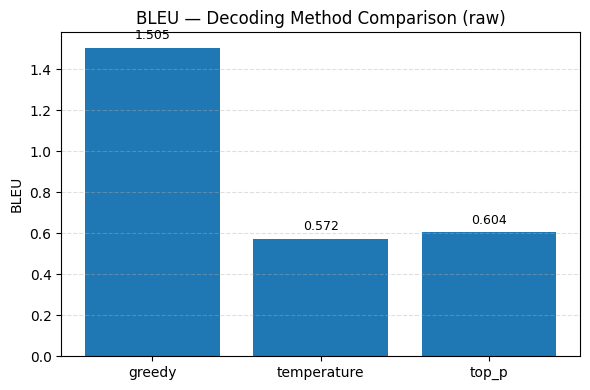

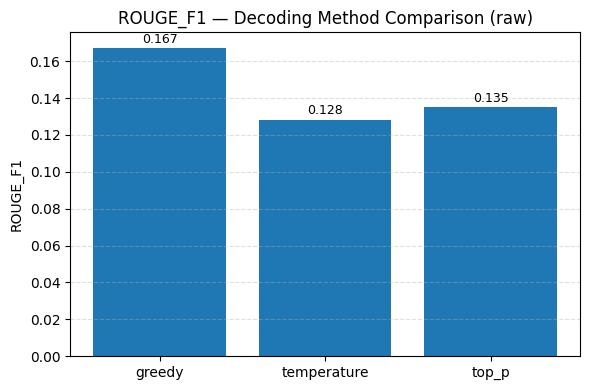

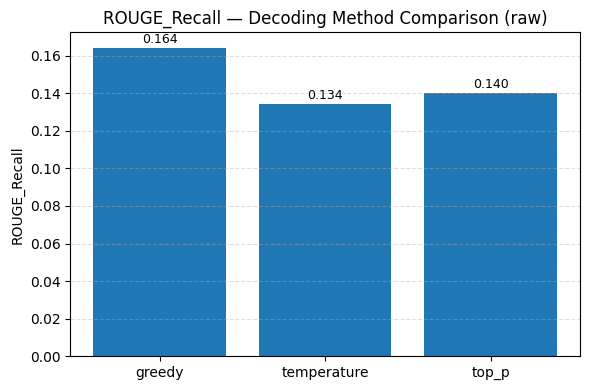

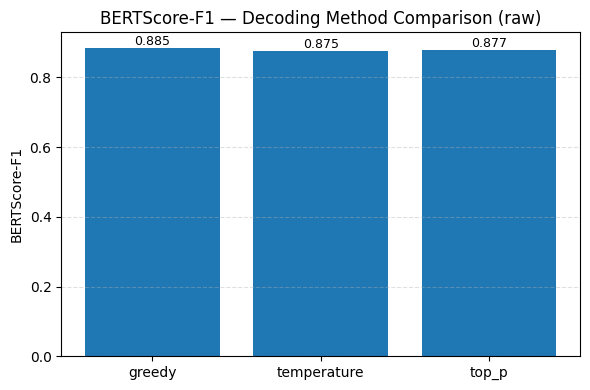

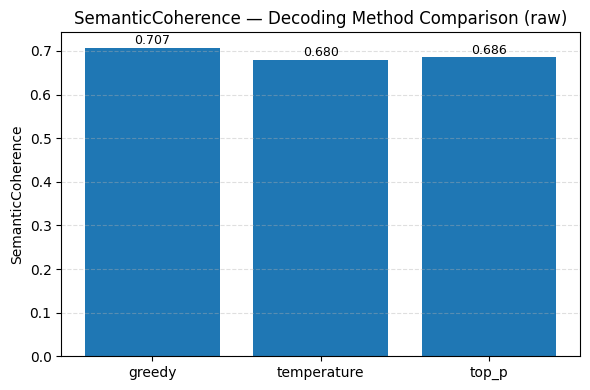

In [30]:
# === Cell 15: Plot metric comparisons (raw, like reference) ===
all_metrics = list(df_results.columns)
core_metrics = [
    m for m in all_metrics if "perplex" not in m.lower() and "ppl" not in m.lower()
]

if not core_metrics:
    print("No core metrics found (only perplexity).")
else:
    for metric in core_metrics:
        plt.figure(figsize=(6, 4))
        vals = df_results[metric].astype(float)
        bars = plt.bar(vals.index, vals.values)

        for bar, v in zip(bars, vals.values):
            offset = (max(vals) - min(vals)) * 0.03 if max(vals) != min(vals) else 0.02
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                v + offset,
                f"{v:.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

        plt.ylabel(metric)
        plt.title(f"{metric} — Decoding Method Comparison (raw)")
        plt.grid(axis="y", linestyle="--", alpha=0.4)
        plt.tight_layout()
        plt.show()

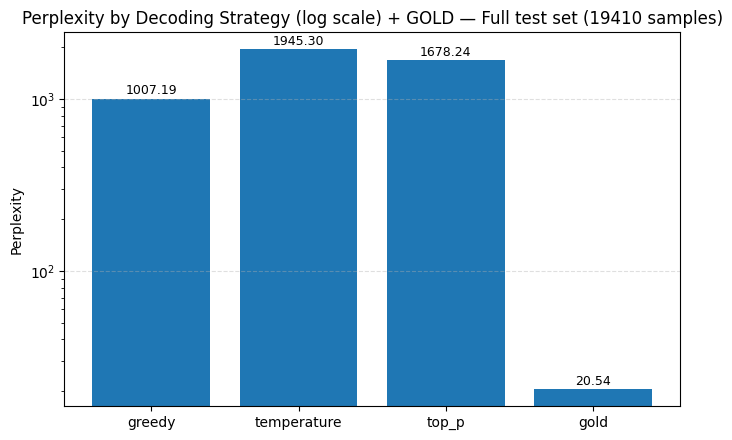

In [31]:
# === Cell 16: Perplexity plot (strategies + GOLD, log scale) ===
perp_vals = {}

ppl_cols = [
    c for c in df_results.columns if "perplex" in c.lower() or "ppl" in c.lower()
]
if ppl_cols:
    ppl_col = ppl_cols[0]
    for dec in df_results.index:
        val = df_results.loc[dec, ppl_col]
        perp_vals[dec] = float(val) if not pd.isna(val) else np.nan
else:
    for dec in ["greedy", "temperature", "top_p"]:
        perp_vals[dec] = np.nan

labels = list(perp_vals.keys()) + ["gold"]
values = list(perp_vals.values()) + [gold_ppl]

plt.figure(figsize=(7, 4.5))
bars = plt.bar(labels, values)
plt.yscale("log")
plt.title(
    f"Perplexity by Decoding Strategy (log scale) + GOLD — Full test set ({len(_prompts)} samples)"
)
plt.ylabel("Perplexity")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar, val in zip(bars, values):
    if np.isnan(val):
        ann = "NaN"
        ypos = 1.0
    else:
        ann = f"{val:.2f}"
        ypos = val * 1.02
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        ypos,
        ann,
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

In [32]:
# === Cell 17: Export samples for human evaluation (same style) ===
def export_samples_for_human_eval(model, tokenizer, N_SAMPLES=30, output_dir=OUTPUT_DIR):
    """
    Export a CSV with prompt, gold ending, and three decoding endings
    for manual inspection / human evaluation.
    """
    human_subset = ds["test"].select(
        range(min(N_SAMPLES, len(ds["test"])))
    )
    rows = []
    for ex in human_subset:
        prompt = ex["prompt"]
        gold = ex["target"]
        greedy = generate_completion(model, tokenizer, prompt, decoding="greedy")
        temp = generate_completion(model, tokenizer, prompt, decoding="temperature")
        top_p_pred = generate_completion(model, tokenizer, prompt, decoding="top_p")
        rows.append(
            {
                "prompt": prompt,
                "gold_ending": gold,
                "greedy_ending": greedy,
                "temperature_ending": temp,
                "top_p_ending": top_p_pred,
            }
        )
    df_human = pd.DataFrame(rows)
    os.makedirs(output_dir, exist_ok=True)
    csv_path = os.path.join(
        output_dir, "distilgpt2_story_samples_for_human_eval.csv"
    )
    df_human.to_csv(csv_path, index=False)
    return csv_path

# Optional: actually export
csv_path = export_samples_for_human_eval(model, tokenizer, N_SAMPLES=30, output_dir=OUTPUT_DIR)
print("Saved examples for human evaluation to:", csv_path)

Saved examples for human evaluation to: /content/distilgpt2_lora_rocstories/distilgpt2_story_samples_for_human_eval.csv
